## LSTM for Coffee Price Forecasting

# 1. Environment Setup

In [1]:
from IPython.display import display, HTML

display(HTML("<style>.container {width: 100% !important;}</style>"))

## 1.1. Library Imports

In [2]:
import torch
import subprocess
import sys
import numpy as np

import torch
import torchvision

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

## 1.2. GPU Check

In [3]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device Name:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA is not available.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 91900
Device Name: NVIDIA GeForce RTX 5070
Device: cuda


## 1.3. Export requirements

In [4]:
def export_requirements():
    try:
        result = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                                capture_output=True,
                                text=True,
                                check=True)
        with open('requirements.txt', 'w') as f:
            f.write(result.stdout)
        print('requirements.txt file generated successfully.')
    except subprocess.CalledProcessError as e:
        print('error:', e)


export_requirements()

requirements.txt file generated successfully.


# 2. Dataset

In [5]:
df = pd.read_csv('data/dataset_final.csv')

df

,date,preco_cafe,cambio_brl,geada_Machado,geada_Manhuacu,geada_Patrocinio,geada_Varginha,precip_mm_sum_Machado,precip_mm_sum_Manhuacu,precip_mm_sum_Patrocinio,...,temp_max_C_max_Patrocinio,temp_max_C_max_Varginha,temp_min_C_min_Machado,temp_min_C_min_Manhuacu,temp_min_C_min_Patrocinio,temp_min_C_min_Varginha,umidade_pct_mean_Machado,umidade_pct_mean_Manhuacu,umidade_pct_mean_Patrocinio,umidade_pct_mean_Varginha
0,2019-01-02,99.500000,3.8799,0,0,0,0,0.0,0.0,0.2,...,28.1,30.100000,19.3,18.3,16.4,18.600000,82.208333,78.166667,84.333333,75.833333
1,2019-01-03,102.150002,3.7863,0,0,0,0,4.4,0.0,0.0,...,31.3,30.300000,19.4,19.1,16.9,19.800000,86.583333,69.875000,74.916667,80.208333
2,2019-01-04,101.599998,3.7551,0,0,0,0,60.4,3.6,4.2,...,25.8,25.400000,18.9,18.8,19.4,19.200000,92.875000,75.666667,83.375000,91.291667
3,2019-01-07,102.750000,3.6612,0,0,0,0,0.0,0.0,0.0,...,30.9,21.700000,19.2,19.3,15.6,18.500000,66.250000,76.958333,70.458333,87.600000
4,2019-01-08,105.050003,3.7341,0,0,0,0,0.0,0.0,0.2,...,32.1,21.886111,20.2,16.4,15.9,18.558333,65.375000,73.625000,75.458333,87.327381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1757,2025-12-23,346.950012,5.5900,0,0,0,0,0.0,0.0,0.0,...,30.1,27.900000,20.1,18.8,15.0,26.500000,56.250000,75.608696,72.956522,78.000000
1758,2025-12-24,345.149994,5.5185,0,0,0,0,0.0,0.4,0.0,...,32.6,27.900000,21.2,19.6,16.1,26.500000,50.875000,77.000000,69.166667,78.000000
1759,2025-12-26,350.250000,5.5195,0,0,0,0,0.0,0.0,0.0,...,34.7,27.900000,23.7,17.3,15.9,26.500000,61.750000,62.947368,67.000000,78.000000
1760,2025-12-29,352.149994,5.5425,0,0,0,0,0.0,5.6,0.2,...,33.7,27.900000,21.9,19.0,17.4,26.500000,85.000000,70.958333,77.625000,78.000000


## 2.1. Dataset overview

In [6]:
print("=== Shape ===")
print(f"  {df.shape[0]} rows  ×  {df.shape[1]} columns")

print("\n=== Period ===")
df["date"] = pd.to_datetime(df["date"])
print(f"  {df['date'].min().date()}  →  {df['date'].max().date()}")

=== Shape ===
  1762 rows  ×  27 columns

=== Period ===
  2019-01-02  →  2025-12-30


In [7]:
print("\n=== Dtypes & Missing ===")
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing%": (df.isnull().mean() * 100).round(2),
})
print(summary.to_string())


=== Dtypes & Missing ===
                                      dtype  missing  missing%
date                         datetime64[us]        0       0.0
preco_cafe                          float64        0       0.0
cambio_brl                          float64        0       0.0
geada_Machado                         int64        0       0.0
geada_Manhuacu                        int64        0       0.0
geada_Patrocinio                      int64        0       0.0
geada_Varginha                        int64        0       0.0
precip_mm_sum_Machado               float64        0       0.0
precip_mm_sum_Manhuacu              float64        0       0.0
precip_mm_sum_Patrocinio            float64        0       0.0
precip_mm_sum_Varginha              float64        0       0.0
temp_ar_C_mean_Machado              float64        0       0.0
temp_ar_C_mean_Manhuacu             float64        0       0.0
temp_ar_C_mean_Patrocinio           float64        0       0.0
temp_ar_C_mean_Varginha      

### 2.1.1. Market variables time series

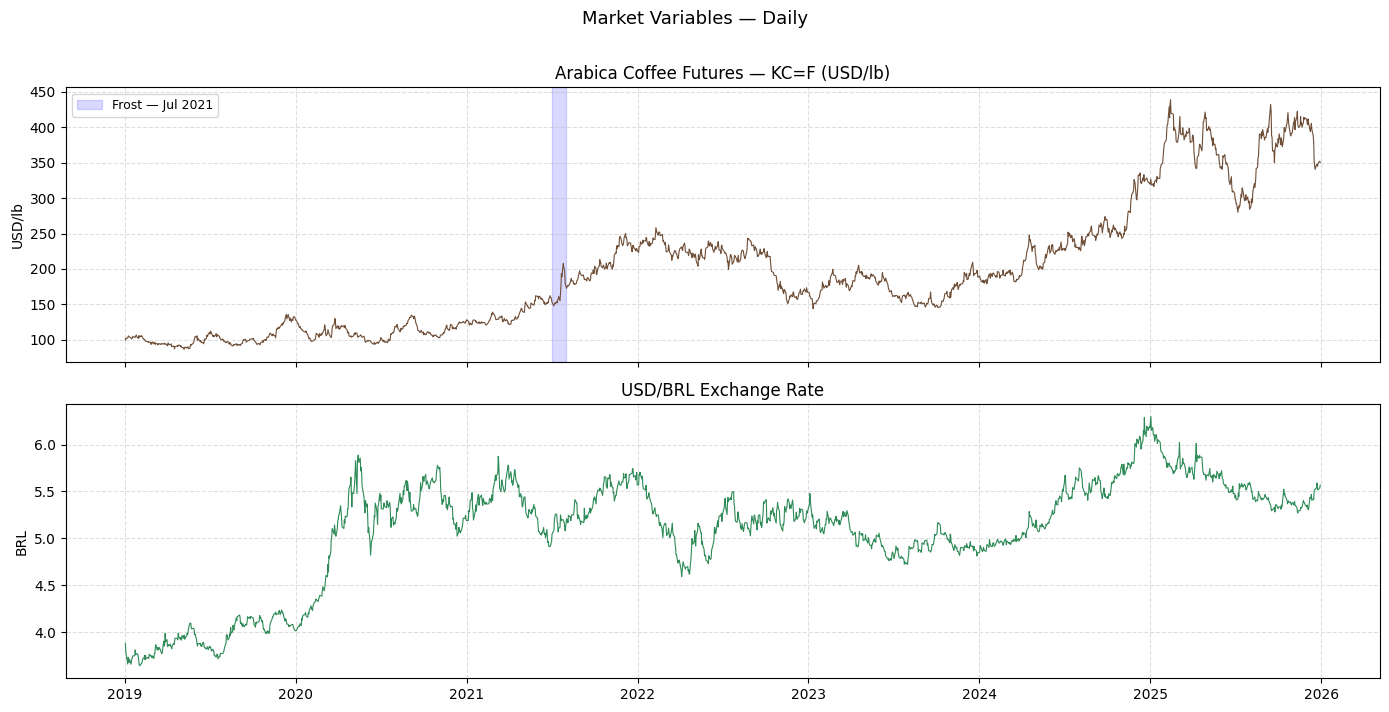

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Market Variables — Daily", fontsize=13, y=1.01)

axes[0].plot(df["date"], df["preco_cafe"], color="#6F4E37", lw=0.8)
axes[0].set_title("Arabica Coffee Futures — KC=F (USD/lb)")
axes[0].set_ylabel("USD/lb")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[0].axvspan(pd.Timestamp("2021-07-01"), pd.Timestamp("2021-07-31"),
                color="blue", alpha=0.15, label="Frost — Jul 2021")
axes[0].legend(fontsize=9)

axes[1].plot(df["date"], df["cambio_brl"], color="#2E8B57", lw=0.8)
axes[1].set_title("USD/BRL Exchange Rate")
axes[1].set_ylabel("BRL")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 2.1.2. Statistical Distribution

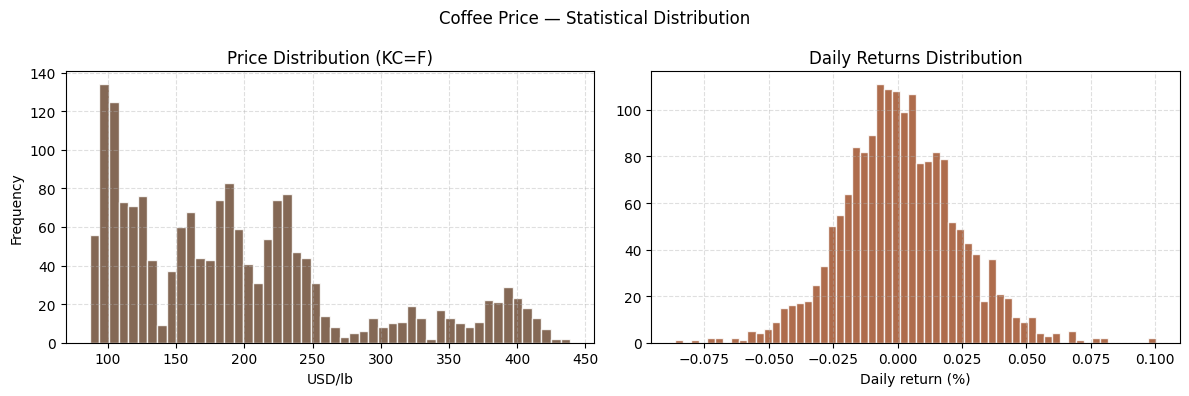

Skewness: 0.931
Kurtosis: 0.070


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["preco_cafe"], bins=50, color="#6F4E37", edgecolor="white", alpha=0.85)
axes[0].set_title("Price Distribution (KC=F)")
axes[0].set_xlabel("USD/lb")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, linestyle="--", alpha=0.4)

retorno = df["preco_cafe"].pct_change().dropna()
axes[1].hist(retorno, bins=60, color="#A0522D", edgecolor="white", alpha=0.85)
axes[1].set_title("Daily Returns Distribution")
axes[1].set_xlabel("Daily return (%)")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Coffee Price — Statistical Distribution", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Skewness: {df['preco_cafe'].skew():.3f}")
print(f"Kurtosis: {df['preco_cafe'].kurt():.3f}")

### 2.1.3. Pearson Correlation

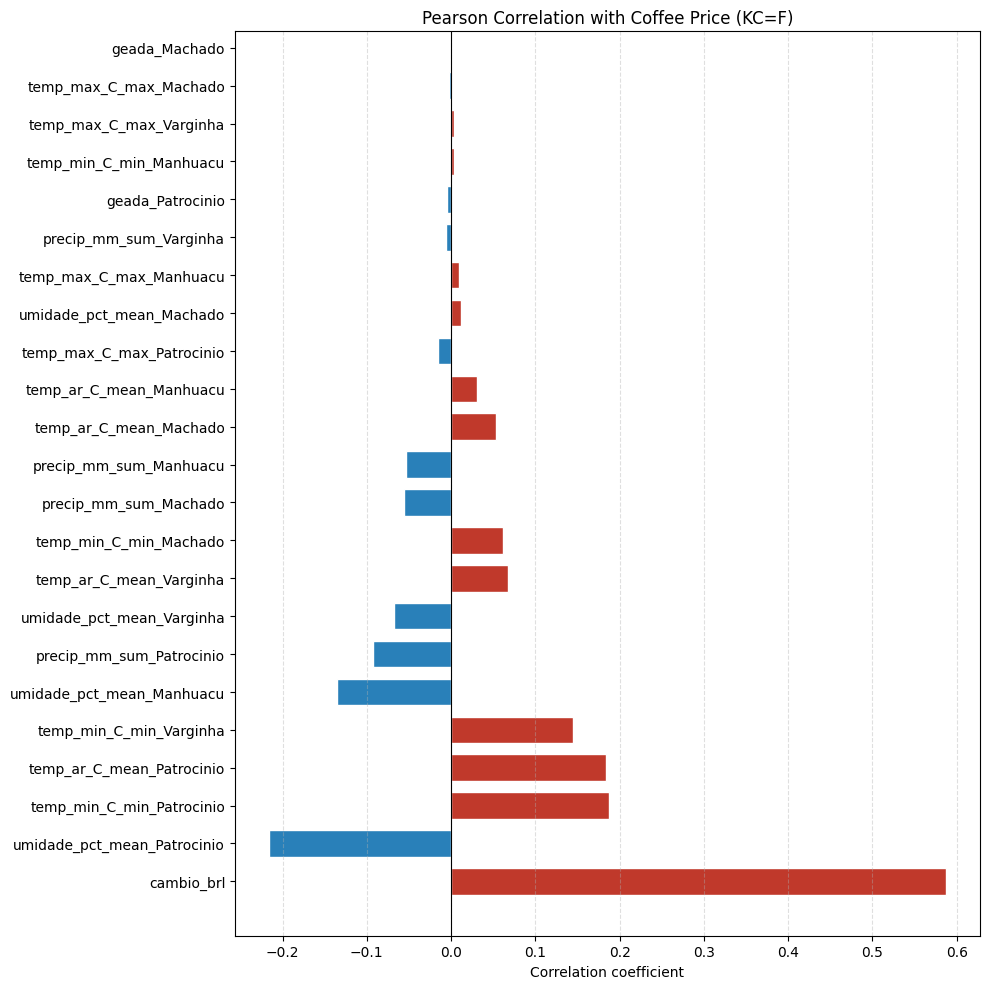

Top 10 most correlated features:
cambio_brl                     0.587
umidade_pct_mean_Patrocinio   -0.216
temp_min_C_min_Patrocinio      0.188
temp_ar_C_mean_Patrocinio      0.184
temp_min_C_min_Varginha        0.144
umidade_pct_mean_Manhuacu     -0.135
precip_mm_sum_Patrocinio      -0.093
umidade_pct_mean_Varginha     -0.068
temp_ar_C_mean_Varginha        0.068
temp_min_C_min_Machado         0.061

Top 10 least correlated (candidates to drop):
umidade_pct_mean_Machado    0.011
temp_max_C_max_Manhuacu     0.010
precip_mm_sum_Varginha     -0.007
geada_Patrocinio           -0.004
temp_min_C_min_Manhuacu     0.004
temp_max_C_max_Varginha     0.004
temp_max_C_max_Machado     -0.002
geada_Machado                 NaN
geada_Manhuacu                NaN
geada_Varginha                NaN


In [10]:
corr = df.drop(columns=["date"]).corr()["preco_cafe"].drop("preco_cafe")
corr = corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#C0392B" if v > 0 else "#2980B9" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Pearson Correlation with Coffee Price (KC=F)", fontsize=12)
ax.set_xlabel("Correlation coefficient")
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Top 10 most correlated features:")
print(corr.head(10).round(3).to_string())
print("\nTop 10 least correlated (candidates to drop):")
print(corr.tail(10).round(3).to_string())

# 3. Preprocessing

## 3.1. Drop frost columns

Drop: geada_* — todas as colunas de geada apresentaram NaN na correlação, indicando variância zero no período 2019–2025 (nenhum registro de temp < 0°C nas estações monitoradas). Colunas constantes não contribuem para o aprendizado do modelo e introduzem ruído.

In [11]:
cols_geada = [c for c in df.columns if "geada" in c]
print(f"Colunas removidas: {cols_geada}")

df = df.drop(columns=cols_geada)
print(f"Shape após drop geada: {df.shape}")

Colunas removidas: ['geada_Machado', 'geada_Manhuacu', 'geada_Patrocinio', 'geada_Varginha']
Shape após drop geada: (1762, 23)


## 3.2. Drop columns with correlation next to zero

Drop: features com |correlação| < 0.03 com preco_cafe.
Correlação de Pearson abaixo desse limiar indica relação linear desprezível com o target. Remover essas features reduz dimensionalidade sem perda de poder preditivo, diminuindo o risco de overfitting.

In [12]:
corr_target = df.drop(columns=["date"]).corr()["preco_cafe"].drop("preco_cafe")

THRESHOLD = 0.03
cols_baixa_corr = corr_target[corr_target.abs() < THRESHOLD].index.tolist()

print(f"Features removidas por baixa correlação (|r| < {THRESHOLD}):")
for c in cols_baixa_corr:
    print(f"  {c:45s}  r = {corr_target[c]:.4f}")

df = df.drop(columns=cols_baixa_corr)
print(f"\nShape após drop correlação fraca: {df.shape}")
print(f"Colunas restantes: {df.columns.tolist()}")

Features removidas por baixa correlação (|r| < 0.03):
  precip_mm_sum_Varginha                         r = -0.0065
  temp_max_C_max_Machado                         r = -0.0025
  temp_max_C_max_Manhuacu                        r = 0.0095
  temp_max_C_max_Patrocinio                      r = -0.0154
  temp_max_C_max_Varginha                        r = 0.0038
  temp_min_C_min_Manhuacu                        r = 0.0040
  umidade_pct_mean_Machado                       r = 0.0115

Shape após drop correlação fraca: (1762, 16)
Colunas restantes: ['date', 'preco_cafe', 'cambio_brl', 'precip_mm_sum_Machado', 'precip_mm_sum_Manhuacu', 'precip_mm_sum_Patrocinio', 'temp_ar_C_mean_Machado', 'temp_ar_C_mean_Manhuacu', 'temp_ar_C_mean_Patrocinio', 'temp_ar_C_mean_Varginha', 'temp_min_C_min_Machado', 'temp_min_C_min_Patrocinio', 'temp_min_C_min_Varginha', 'umidade_pct_mean_Manhuacu', 'umidade_pct_mean_Patrocinio', 'umidade_pct_mean_Varginha']


In [14]:
print(f"Shape final:  {df.shape}")
print(f"Período:      {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Missing:      {df.isnull().sum().sum()} valores ausentes")
print(f"\nFeatures para o modelo ({df.shape[1] - 2}):")  # -2 = date + preco_cafe
for c in df.columns:
    if c not in ("date", "preco_cafe"):
        r = corr_target.get(c, float("nan"))
        print(f"  {c:45s}  r = {r:.4f}")

df.to_csv("data/dataset_model.csv", index=False)
print("\nSalvo → data/dataset_model.csv ✓")

Shape final:  (1762, 16)
Período:      2019-01-02 → 2025-12-30
Missing:      0 valores ausentes

Features para o modelo (14):
  cambio_brl                                     r = 0.5874
  precip_mm_sum_Machado                          r = -0.0564
  precip_mm_sum_Manhuacu                         r = -0.0533
  precip_mm_sum_Patrocinio                       r = -0.0927
  temp_ar_C_mean_Machado                         r = 0.0530
  temp_ar_C_mean_Manhuacu                        r = 0.0303
  temp_ar_C_mean_Patrocinio                      r = 0.1841
  temp_ar_C_mean_Varginha                        r = 0.0678
  temp_min_C_min_Machado                         r = 0.0610
  temp_min_C_min_Patrocinio                      r = 0.1876
  temp_min_C_min_Varginha                        r = 0.1445
  umidade_pct_mean_Manhuacu                      r = -0.1350
  umidade_pct_mean_Patrocinio                    r = -0.2162
  umidade_pct_mean_Varginha                      r = -0.0680

Salvo → data/dataset_model.